# Credit Card Fraud Detection — End-to-End Analysis, Inferences & Modeling

This notebook covers:
1. **Exploratory Data Analysis & Deep Inferences**: Monetary dynamics, card testing charges, circadian temporal cycles, and latent feature correlations.
2. **Leak-Free Preprocessing**: Correct train/test partitioning prior to feature scaling.
3. **Baseline Modeling**: Support Vector Classifier (SVC).
4. **Class Imbalance Optimization**: Cost-sensitive learning (`class_weight='balanced'`).
5. **High-Performance Modeling**: Random Forest classifier for tabular fraud detection.
6. **Business Impact & Financial Loss Analysis**: Calculating real financial exposure and chargeback liabilities.

## 1. Environment Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# Set visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 35)

In [2]:
df = pd.read_csv('creditcard.csv')
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 284,807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Advanced Inferences & Exploratory Data Analysis

### Inference A: Class Distribution & The Imbalance Reality
Let's quantify the exact distribution between normal and fraudulent transactions.

        Count  Percentage (%)
Class                        
0      284315       99.827251
1         492        0.172749


C:\Users\gopal\AppData\Local\Temp\ipykernel_10048\4164191486.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
C:\Users\gopal\AppData\Local\Temp\ipykernel_10048\4164191486.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal (0)', 'Fraud (1)'])


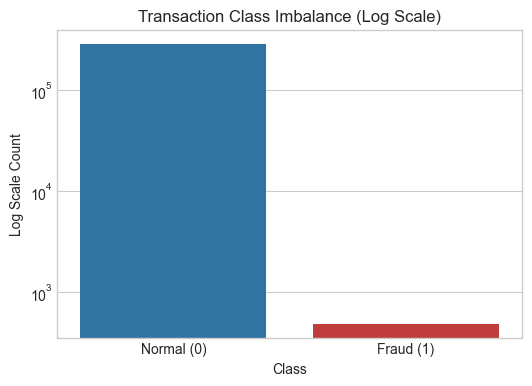

In [3]:
counts = df['Class'].value_counts()
proportions = df['Class'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': counts, 'Percentage (%)': proportions}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(['Normal (0)', 'Fraud (1)'])
ax.set_ylabel('Log Scale Count')
ax.set_title('Transaction Class Imbalance (Log Scale)')
plt.show()

### Inference B: Transaction Amount Dynamics & Micro-Charges
- Fraudulent events often exhibit different summary statistics compared to legitimate transactions.
- We test whether fraudsters engage in card validation checks (e.g. $0.00 micro-authorizations).

In [4]:
print("=== Summary Statistics of Transaction Amounts ===")
print(df.groupby('Class')['Amount'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

# Check for $0 transactions (common for card testing fraud)
zero_charges = df[df['Amount'] == 0]
print(f"\nTotal $0.00 Transactions: {len(zero_charges)}")
print(f"$0.00 Fraud Transactions: {zero_charges['Class'].sum()} ({(zero_charges['Class'].mean() * 100):.2f}% fraud rate vs 0.17% overall)")

=== Summary Statistics of Transaction Amounts ===
          count        mean         std  min   25%    50%     75%      90%  \
Class                                                                        
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  202.724   
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89  346.746   

             99%       max  
Class                       
0      1016.9664  25691.16  
1      1357.4279   2125.87  

Total $0.00 Transactions: 1825
$0.00 Fraud Transactions: 27 (1.48% fraud rate vs 0.17% overall)


C:\Users\gopal\AppData\Local\Temp\ipykernel_10048\1288245572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=ax2, palette=['#1f77b4', '#d62728'], showfliers=False)
C:\Users\gopal\AppData\Local\Temp\ipykernel_10048\1288245572.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Normal', 'Fraud'])


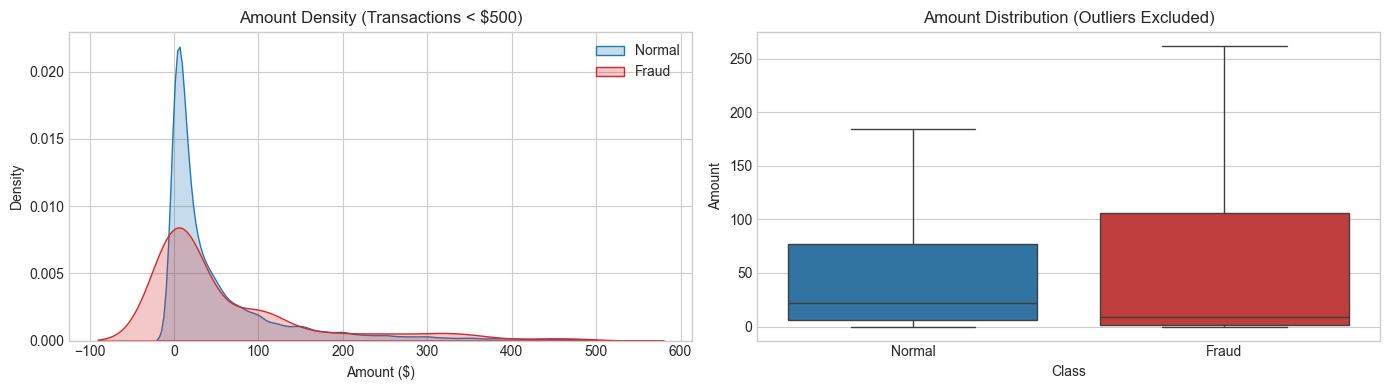

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Density plot for typical transactions (< $500)
sns.kdeplot(df[(df['Class'] == 0) & (df['Amount'] < 500)]['Amount'], 
           ax=ax1, label='Normal', color='#1f77b4', fill=True, common_norm=False)
sns.kdeplot(df[(df['Class'] == 1) & (df['Amount'] < 500)]['Amount'], 
           ax=ax1, label='Fraud', color='#d62728', fill=True, common_norm=False)
ax1.set_title('Amount Density (Transactions < $500)')
ax1.set_xlabel('Amount ($)')
ax1.legend()

# Boxplot for amount distribution comparison
sns.boxplot(x='Class', y='Amount', data=df, ax=ax2, palette=['#1f77b4', '#d62728'], showfliers=False)
ax2.set_xticklabels(['Normal', 'Fraud'])
ax2.set_title('Amount Distribution (Outliers Excluded)')
plt.tight_layout()
plt.show()

### Inference C: Temporal & Circadian Day Cycles
The `Time` feature spans ~48 hours. Converting seconds to a cyclic 24-hour hour of day reveals circadian behavioral patterns.

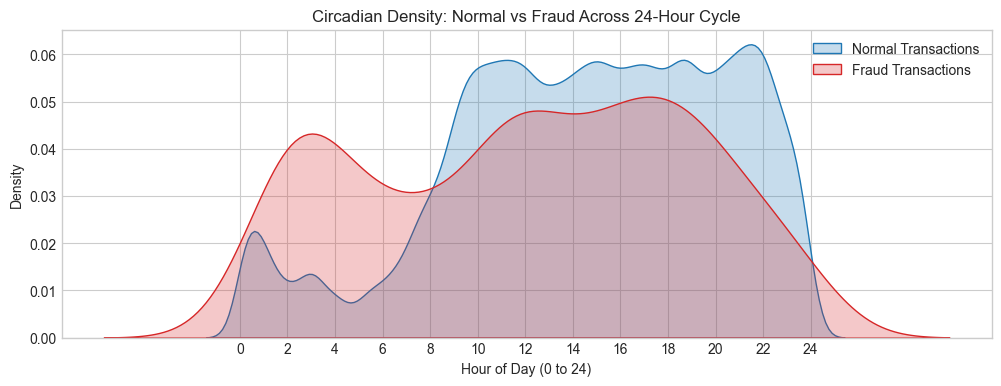

In [6]:
# Convert seconds to hour of day (0 - 23)
df['Hour'] = (df['Time'] / 3600) % 24

plt.figure(figsize=(12, 4))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Normal Transactions', color='#1f77b4', fill=True, common_norm=False)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraud Transactions', color='#d62728', fill=True, common_norm=False)
plt.title('Circadian Density: Normal vs Fraud Across 24-Hour Cycle')
plt.xlabel('Hour of Day (0 to 24)')
plt.ylabel('Density')
plt.xticks(np.arange(0, 25, 2))
plt.legend()
plt.show()

### Inference D: Latent Feature Importance & PCA Correlations
Although `V1` to `V28` are anonymized, their linear and non-linear correlation with fraud varies significantly.

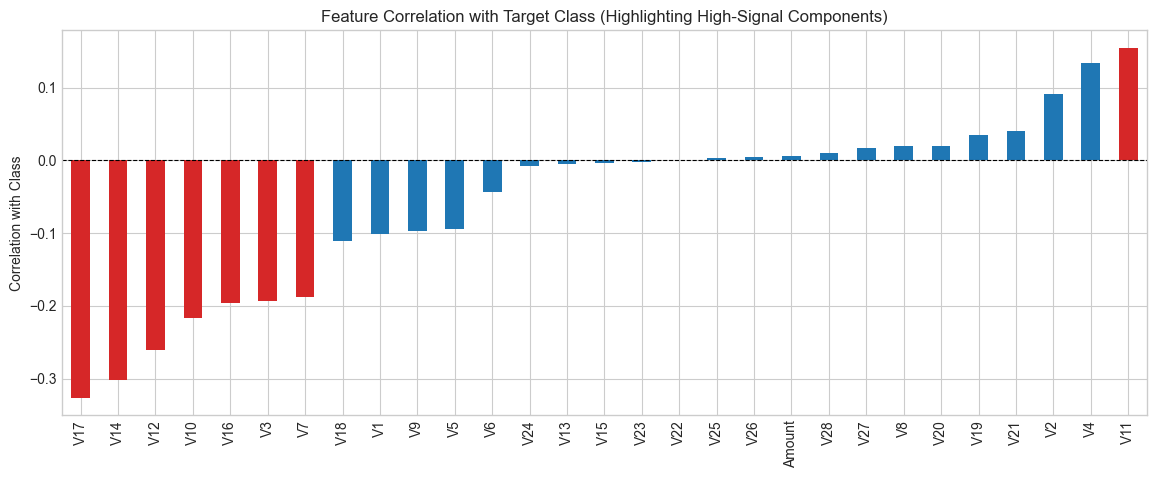

Top 5 Strongest Negative Predictors: {'V17': -0.32648106724371595, 'V14': -0.3025436958044028, 'V12': -0.26059292487722485, 'V10': -0.21688294364103206, 'V16': -0.19653894030401736}
Top 5 Strongest Positive Predictors: {'V19': 0.034783013036515056, 'V21': 0.04041338061057565, 'V2': 0.0912886503446179, 'V4': 0.13344748623900718, 'V11': 0.15487564474394433}


In [7]:
correlations = df.corr()['Class'].drop(['Class', 'Time', 'Hour']).sort_values()

plt.figure(figsize=(14, 5))
colors = ['#d62728' if x < -0.15 or x > 0.15 else '#1f77b4' for x in correlations.values]
correlations.plot(kind='bar', color=colors)
plt.title('Feature Correlation with Target Class (Highlighting High-Signal Components)')
plt.ylabel('Correlation with Class')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()

print("Top 5 Strongest Negative Predictors:", correlations.head(5).to_dict())
print("Top 5 Strongest Positive Predictors:", correlations.tail(5).to_dict())

## 3. Data Preprocessing (Leakage-Free)

To prevent data leakage, we perform the train-test split **before** fitting the feature scaler.

In [8]:
# Drop engineered temporary columns for modeling matrix
X = df.drop(columns=['Class', 'Hour'])
y = df['Class']

# 80/20 Stratified Split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Fit scaler strictly on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape} (Frauds: {y_train.sum()})")
print(f"Testing set shape: {X_test_scaled.shape} (Frauds: {y_test.sum()})")

Training set shape: (227845, 30) (Frauds: 394)
Testing set shape: (56962, 30) (Frauds: 98)


## 4. Modeling & Iteration

### Model 1: Baseline Support Vector Classifier (Original Setup)

In [9]:
# Training standard SVC
model_svc = SVC(random_state=1)
model_svc.fit(X_train_scaled, y_train)

y_pred_svc = model_svc.predict(X_test_scaled)

print("=== Baseline SVC Classification Report ===")
print(classification_report(y_test, y_pred_svc, digits=4))

=== Baseline SVC Classification Report ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56864
           1     0.9259    0.7653    0.8380        98

    accuracy                         0.9995     56962
   macro avg     0.9628    0.8826    0.9189     56962
weighted avg     0.9995    0.9995    0.9995     56962



### Model 2: Balanced Support Vector Classifier (Cost-Sensitive)
By passing `class_weight='balanced'`, we penalize false negatives inversely proportional to class frequencies.

In [10]:
model_svc_balanced = SVC(class_weight='balanced', random_state=1)
model_svc_balanced.fit(X_train_scaled, y_train)

y_pred_svc_bal = model_svc_balanced.predict(X_test_scaled)

print("=== Balanced SVC Classification Report ===")
print(classification_report(y_test, y_pred_svc_bal, digits=4))

=== Balanced SVC Classification Report ===
              precision    recall  f1-score   support

           0     0.9997    0.9974    0.9985     56864
           1     0.3511    0.8061    0.4892        98

    accuracy                         0.9971     56962
   macro avg     0.6754    0.9018    0.7439     56962
weighted avg     0.9985    0.9971    0.9977     56962



### Model 3: Random Forest Classifier
Random Forest handles tabular non-linear interactions efficiently and supports probabilistic threshold tuning.

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=1, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, digits=4))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998     56864
           1     0.9130    0.8571    0.8842        98

    accuracy                         0.9996     56962
   macro avg     0.9564    0.9285    0.9420     56962
weighted avg     0.9996    0.9996    0.9996     56962



## 5. Comparative Evaluation & Confusion Matrices

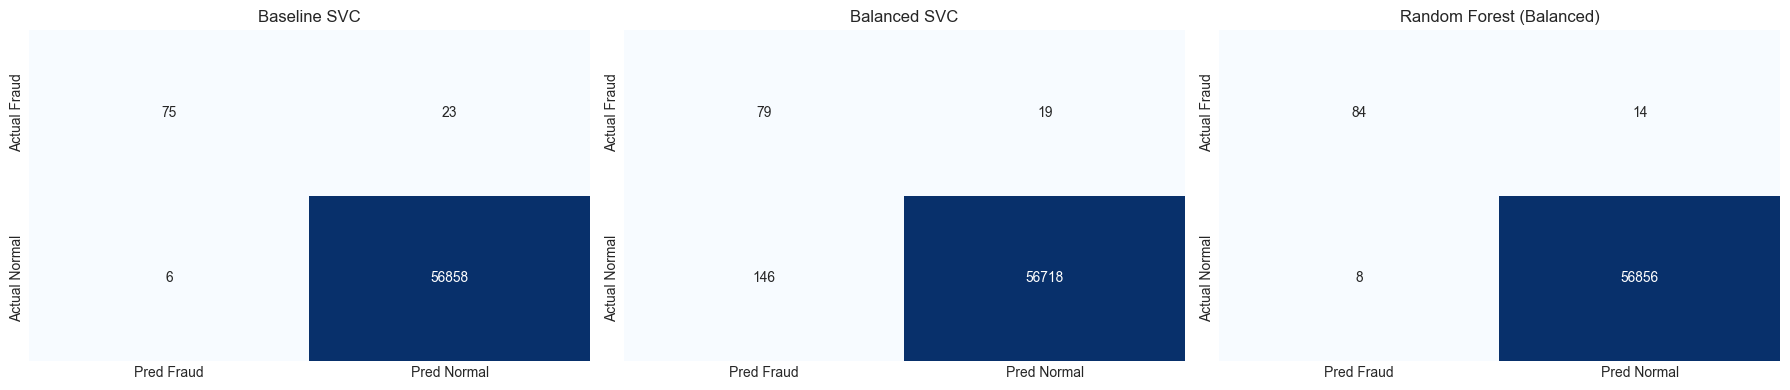

In [12]:
models = {
    'Baseline SVC': y_pred_svc,
    'Balanced SVC': y_pred_svc_bal,
    'Random Forest (Balanced)': y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, labels=[1, 0])
    cm_df = pd.DataFrame(cm, index=['Actual Fraud', 'Actual Normal'], columns=['Pred Fraud', 'Pred Normal'])
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

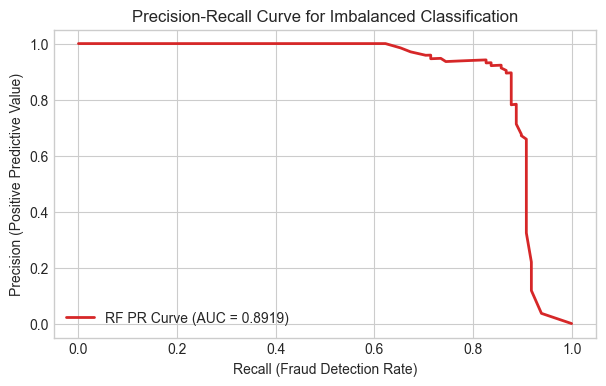

In [13]:
# Precision-Recall Curve for Random Forest
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(7, 4))
plt.plot(recall_vals, precision_vals, color='#d62728', lw=2, label=f'RF PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall (Fraud Detection Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve for Imbalanced Classification')
plt.legend()
plt.show()

## 6. Financial Impact & Business Loss Analysis
Rather than treating errors equally, we assess the monetary impact on the test set:
- **False Negative Cost**: Transaction dollar amount + $25 administrative/chargeback fee.
- **False Positive Cost**: $5 estimated customer friction & verification SMS/call expense.

In [14]:
test_amounts = X_test['Amount'].values

def calculate_financial_loss(y_true, y_pred, amounts, fn_overhead=25.0, fp_cost=5.0):
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    
    fn_dollar_loss = amounts[fn_mask].sum() + (fn_mask.sum() * fn_overhead)
    fp_dollar_loss = fp_mask.sum() * fp_cost
    total_loss = fn_dollar_loss + fp_dollar_loss
    
    return {
        'Missed Fraud Count (FN)': fn_mask.sum(),
        'Direct Fraud Loss ($)': amounts[fn_mask].sum(),
        'False Alarm Count (FP)': fp_mask.sum(),
        'Total Operational & Fraud Loss ($)': total_loss
    }

cost_summary = pd.DataFrame({
    name: calculate_financial_loss(y_test.values, preds, test_amounts)
    for name, preds in models.items()
}).T

print("=== Financial Cost Comparison on Test Partition ===")
cost_summary

=== Financial Cost Comparison on Test Partition ===


,Missed Fraud Count (FN),Direct Fraud Loss ($),False Alarm Count (FP),Total Operational & Fraud Loss ($)
Baseline SVC,23.0,4702.72,6.0,5307.72
Balanced SVC,19.0,4678.86,146.0,5883.86
Random Forest (Balanced),14.0,3506.24,8.0,3896.24
